In [18]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"

fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"
czi_name = "CB7-04_S3.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [3]:
channel = 1
time = 0
img, img_disp = get_frame(czi,time,channel)

In [4]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [5]:
def select_roi(img):
    roi, _ = get_roi_from_result(
    result,
    result['rotate_fn'](img) ,
    pad_left_um=-2500.0,   # expand chip box leftward (µm)
    pad_right_um=-1000.0,  # expand chip box rightward (µm)
    pad_top_um=1000.0,    # pad above & below main channel centre (symmetric)
    pad_bottom_um=1000.0,    # pad above & below main channel centre (symmetric)

)
    return roi

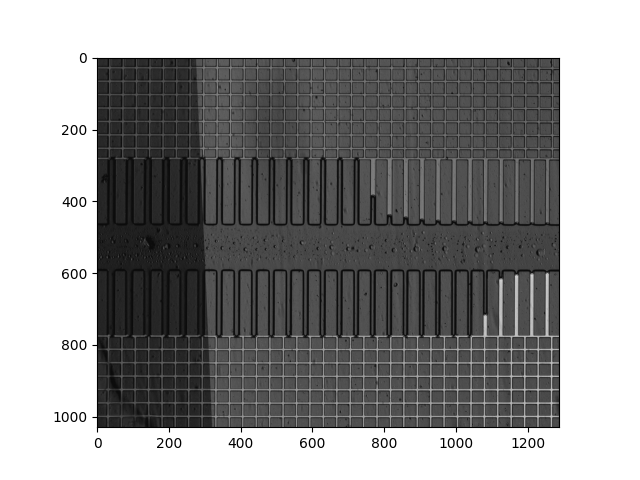

In [6]:

stretch_min = 10
stretch_max = 99.5
channel = 0
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=1,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")

Found 6710 regions

Top 10 regions by size:
  1. Size=70,966 px, mean intensity=0.5830
  2. Size=64,173 px, mean intensity=0.4798
  3. Size=11,700 px, mean intensity=0.3547
  4. Size=5,921 px, mean intensity=0.3538
  5. Size=4,934 px, mean intensity=0.3879
  6. Size=4,824 px, mean intensity=0.3957
  7. Size=4,459 px, mean intensity=0.3779
  8. Size=4,268 px, mean intensity=0.3776
  9. Size=4,267 px, mean intensity=0.3900
  10. Size=3,456 px, mean intensity=0.3861


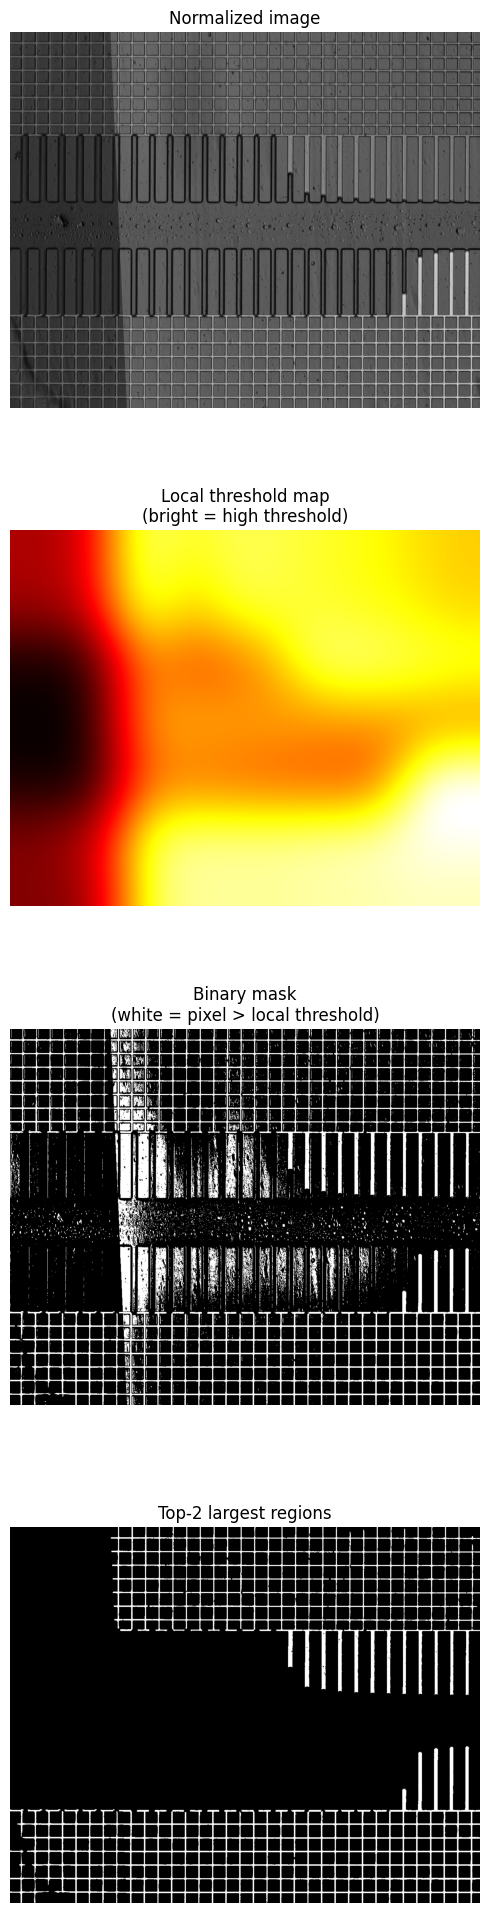

In [52]:
%matplotlib inline
import cv2
from scipy.ndimage import label, gaussian_filter

# Extract ROI
img_roi = select_roi(img)
img_disp_roi = select_roi(img_disp)

# Normalize the image to 0-1 range
img_norm = (img_roi - img_roi.min()) / (img_roi.max() - img_roi.min())

# Parameters
blockSize = 501
C = -15

# Compute the local threshold map explicitly for visualisation
# (replicates what adaptiveThreshold does internally)
sigma_internal = blockSize / 6.0
local_mean = gaussian_filter(img_norm, sigma=sigma_internal)
threshold_map = local_mean - (C / 255.0)

# Apply adaptive thresholding on normalized image
binary_adapt = cv2.adaptiveThreshold(
    (img_norm * 255).astype(np.uint8),
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=blockSize,
    C=C,
).astype(bool)

# Label connected components
lbl, n_regions = label(binary_adapt)

# Get statistics for each region
print(f"Found {n_regions} regions\n")
region_stats = []
for i in range(1, n_regions + 1):
    mask_i = lbl == i
    size = int(mask_i.sum())
    intensity = float(img_norm[mask_i].mean())
    region_stats.append(dict(label=i, size=size, intensity=intensity))

# Sort by size and show top regions
region_stats.sort(key=lambda x: x["size"], reverse=True)
print("Top 10 regions by size:")
for k, s in enumerate(region_stats[:10]):
    print(f"  {k+1}. Size={s['size']:,} px, mean intensity={s['intensity']:.4f}")

# Create mask for top 2 regions
top2_mask = np.zeros_like(binary_adapt)
for s in region_stats[:2]:
    top2_mask[lbl == s["label"]] = True

# Visualise
fig, axes = plt.subplots(4, 1, figsize=(5, 20))
axes[0].imshow(img_norm,      cmap="gray"); axes[0].set_title("Normalized image")
axes[1].imshow(threshold_map, cmap="hot");  axes[1].set_title("Local threshold map\n(bright = high threshold)")
axes[2].imshow(binary_adapt,  cmap="gray"); axes[2].set_title("Binary mask\n(white = pixel > local threshold)")
axes[3].imshow(top2_mask,     cmap="gray"); axes[3].set_title("Top-2 largest regions")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

Found 0 regions

Top 10 regions by size:


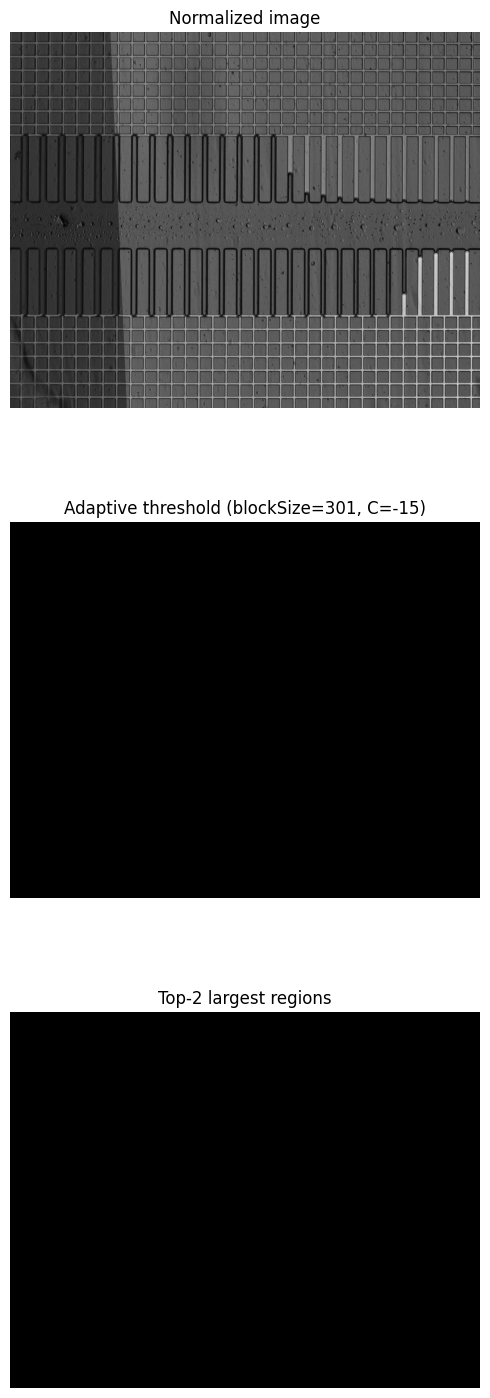

In [47]:
# Adaptive threshold on blurred image
blockSize = 301
C = -15

binary_adapt = cv2.adaptiveThreshold(
    (img_blur * 255).astype(np.uint8),
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=blockSize,
    C=C,
).astype(bool)

# Label connected components
lbl, n_regions = label(binary_adapt)
print(f"Found {n_regions} regions\n")

region_stats = []
for i in range(1, n_regions + 1):
    mask_i = lbl == i
    region_stats.append(dict(label=i, size=int(mask_i.sum()), intensity=float(img_norm[mask_i].mean())))

region_stats.sort(key=lambda x: x["size"], reverse=True)
print("Top 10 regions by size:")
for k, s in enumerate(region_stats[:10]):
    print(f"  {k+1}. Size={s['size']:,} px, mean intensity={s['intensity']:.4f}")

top2_mask = np.zeros_like(binary_adapt)
for s in region_stats[:2]:
    top2_mask[lbl == s["label"]] = True

fig, axes = plt.subplots(3, 1, figsize=(5, 15))
axes[0].imshow(img_norm,     cmap="gray"); axes[0].set_title("Normalized image")
axes[1].imshow(binary_adapt, cmap="gray"); axes[1].set_title(f"Adaptive threshold (blockSize={blockSize}, C={C})")
axes[2].imshow(top2_mask,    cmap="gray"); axes[2].set_title("Top-2 largest regions")
for ax in axes: ax.axis("off")
plt.tight_layout()